## Predicting Uber Ride Cancellations
* Created a fast, interpretable pipeline to predict ride cancellations using Random Forest.
* Built backend for this project using FastAPI
* Created interactive and responsive frontend using HTML, CSS, and JavaScript.
* Deployed complete project pipeline using Git, GitHub on Render and created a live link for the project

## Introduction: Why This Matters
* Ride cancellations lead to lost revenue, wasted resources, and potential customer churn. 
* Predicting cancellations in advance can help ride-hailing platforms improve customer experience, optimize driver allocation, and reduce operational inefficiencies.

## Problem Statement
Can we predict if a customer will cancel an Uber ride before it begins, using only booking metadata?

Task: Binary classification 
Target: target_customer_cancelled (1 = cancelled, 0 = not) 
Note: Labels are imbalanced (~7% cancellations)

## About the Dataset
This dataset is taken from kaggle.

* Name: Uber Ride Analytics 2024
* Size: ~150,000 bookings
* Target: Derived from Booking Status → target_customer_cancelled
* Features: time of day, vehicle type, pickup/drop locations, user/driver ratings, etc.
* Quality: Clean, well-structured, no major missing values

## Project Workflow

* Data Cleaning
* Exploratory Data Analysis (EDA)
* Feature Engineering
* Handle Class Imbalance (undersampling or class weights)
* Train Decision Tree, Random Forest and XGBoost Model
* Evaluate using Recall score, ROC-AUC and F1 score
* Highlight findings and model insights

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load the Dataset

In [2]:
# Load the dataset
df = pd.read_csv("ncr_ride_bookings.csv")

df.head()

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,...,NaN,NaN,NaN,1.0,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,...,NaN,NaN,NaN,NaN,NaN,627.0,13.58,4.9,4.9,Debit Card
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,...,NaN,NaN,NaN,NaN,NaN,416.0,34.02,4.6,5.0,UPI
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,...,NaN,NaN,NaN,NaN,NaN,737.0,48.21,4.1,4.3,UPI


In [3]:
df.shape

(150000, 21)

In [4]:
# Check data types and missing values
print("📌 Data Info:")
df.info()

# 1. change date and time column data type

📌 Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 21 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Date                               150000 non-null  object 
 1   Time                               150000 non-null  object 
 2   Booking ID                         150000 non-null  object 
 3   Booking Status                     150000 non-null  object 
 4   Customer ID                        150000 non-null  object 
 5   Vehicle Type                       150000 non-null  object 
 6   Pickup Location                    150000 non-null  object 
 7   Drop Location                      150000 non-null  object 
 8   Avg VTAT                           139500 non-null  float64
 9   Avg CTAT                           102000 non-null  float64
 10  Cancelled Rides by Customer        10500 non-null   float64
 11  Reason for cancelling by C

In [5]:
print("\n📊 Summary Statistics:")
df.describe()


📊 Summary Statistics:


,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Cancelled Rides by Driver,Incomplete Rides,Booking Value,Ride Distance,Driver Ratings,Customer Rating
count,139500.000000,102000.000000,10500.0,27000.0,9000.0,102000.000000,102000.000000,93000.000000,93000.000000
mean,8.456352,29.149636,1.0,1.0,1.0,508.295912,24.637012,4.230992,4.404584
std,3.773564,8.902577,0.0,0.0,0.0,395.805774,14.002138,0.436871,0.437819
min,2.000000,10.000000,1.0,1.0,1.0,50.000000,1.000000,3.000000,3.000000
25%,5.300000,21.600000,1.0,1.0,1.0,234.000000,12.460000,4.100000,4.200000
50%,8.300000,28.800000,1.0,1.0,1.0,414.000000,23.720000,4.300000,4.500000
75%,11.300000,36.800000,1.0,1.0,1.0,689.000000,36.820000,4.600000,4.800000
max,20.000000,45.000000,1.0,1.0,1.0,4277.000000,50.000000,5.000000,5.000000


In [6]:
print("\n🔍 Null Values per Column:")
print(df.isnull().sum())


🔍 Null Values per Column:
Date                                      0
Time                                      0
Booking ID                                0
Booking Status                            0
Customer ID                               0
Vehicle Type                              0
Pickup Location                           0
Drop Location                             0
Avg VTAT                              10500
Avg CTAT                              48000
Cancelled Rides by Customer          139500
Reason for cancelling by Customer    139500
Cancelled Rides by Driver            123000
Driver Cancellation Reason           123000
Incomplete Rides                     141000
Incomplete Rides Reason              141000
Booking Value                         48000
Ride Distance                         48000
Driver Ratings                        57000
Customer Rating                       57000
Payment Method                        48000
dtype: int64


## 3. Data Preprocessing

### 3.1 Handling Date Time columns

In [7]:
# Convert Date and Time to datetime
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Time'] = pd.to_datetime(df['Time'], format='%H:%M:%S', errors='coerce').dt.time

# Combine Date and Time into a single datetime column
df['datetime'] = pd.to_datetime(df['Date'].astype(str) + " " + df['Time'].astype(str), errors='coerce')

In [8]:
df['hour'] = df['datetime'].dt.hour
df['day'] = df['datetime'].dt.day
df['month'] = df['datetime'].dt.month
df['weekday'] = df['datetime'].dt.dayofweek
df['is_weekend'] = df['weekday'].isin([5, 6])

In [9]:
# Check result
df[['datetime', 'hour', 'day', 'month', 'weekday', 'is_weekend']].head()

,datetime,hour,day,month,weekday,is_weekend
0,2024-03-23 12:29:38,12,23,3,5,True
1,2024-11-29 18:01:39,18,29,11,4,False
2,2024-08-23 08:56:10,8,23,8,4,False
3,2024-10-21 17:17:25,17,21,10,0,False
4,2024-09-16 22:08:00,22,16,9,0,False


In [10]:
df['is_weekend'] = df['is_weekend'].astype(int)

### 3.2 Handling null values
### a. Target Column

In [11]:
df['Cancelled Rides by Customer'].value_counts()

# it means cancelled rides are marked as 1 and not cancelled left empty

Cancelled Rides by Customer
1.0    10500
Name: count, dtype: int64

In [12]:
df['Cancelled Rides by Customer'].notnull().value_counts()

Cancelled Rides by Customer
False    139500
True      10500
Name: count, dtype: int64

In [13]:
# Marking cancelled rides as True and completed rides as false
df['Cancelled Rides by Customer'] = df['Cancelled Rides by Customer'].notnull()

In [14]:
# Target variable
df['target_customer_cancelled'] = df['Cancelled Rides by Customer'].astype(int)

In [15]:
df['target_customer_cancelled'].head()

0    0
1    0
2    0
3    0
4    0
Name: target_customer_cancelled, dtype: int64

In [16]:
# Quick target distribution check
df['target_customer_cancelled'].value_counts(normalize=True)

target_customer_cancelled
0    0.93
1    0.07
Name: proportion, dtype: float64

### b. Other Columns

In [17]:
# Fill CTAT, VTAT, Ride Distance, Booking Value with median
df['Avg VTAT'] = df['Avg VTAT'].fillna(df['Avg VTAT'].median())
df['Avg CTAT'] = df['Avg CTAT'].fillna(df['Avg CTAT'].median())
df['Ride Distance'] = df['Ride Distance'].fillna(df['Ride Distance'].median())
df['Booking Value'] = df['Booking Value'].fillna(df['Booking Value'].median())
df['Driver Ratings'] = df['Driver Ratings'].fillna(df['Driver Ratings'].median())
df['Customer Rating'] = df['Customer Rating'].fillna(df['Customer Rating'].median())

# Fill payment method with "missing"
df['Payment Method'] = df['Payment Method'].fillna("missing")

## 4. EDA for Customer Cancellations

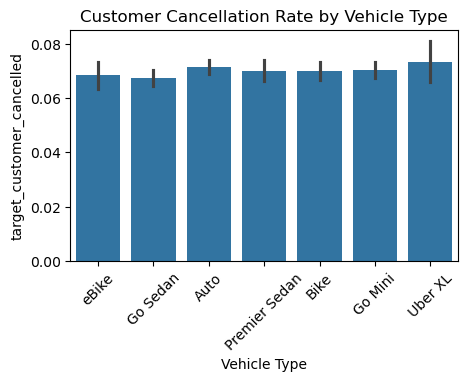

In [18]:
# 1. Cancellation Rate by Vehicle Type
plt.figure(figsize=(5,3))
sns.barplot(x='Vehicle Type', y='target_customer_cancelled', data=df)
plt.title("Customer Cancellation Rate by Vehicle Type")
plt.xticks(rotation=45)
plt.show()

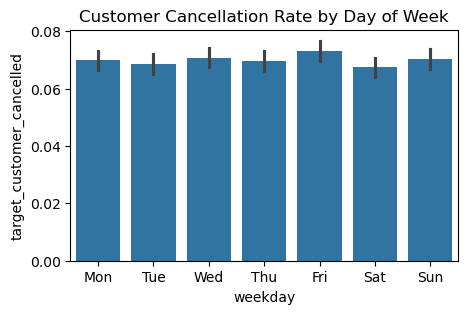

In [19]:
# 2. Cancellation Rate by Day of Week
plt.figure(figsize=(5, 3))
sns.barplot(data=df, x='weekday', y='target_customer_cancelled')
plt.title("Customer Cancellation Rate by Day of Week")
plt.xticks(ticks=range(7), labels=["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])
plt.show()

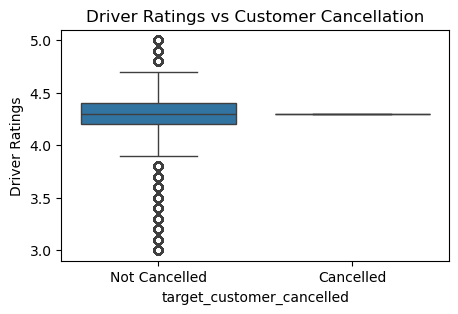

In [20]:
# 3. Driver Rating vs Cancellation
plt.figure(figsize=(5, 3))
sns.boxplot(data=df, x='target_customer_cancelled', y='Driver Ratings')
plt.title("Driver Ratings vs Customer Cancellation")
plt.xticks([0, 1], ['Not Cancelled', 'Cancelled'])
plt.show()

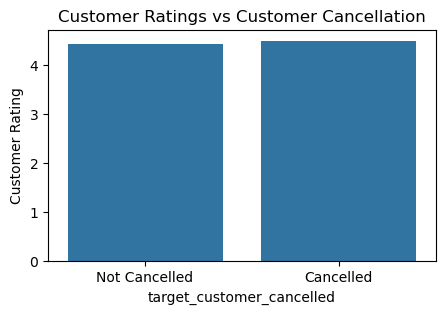

In [21]:
# 4. Customer Rating vs Cancellation
plt.figure(figsize=(5,3))
sns.barplot(data=df, x='target_customer_cancelled', y='Customer Rating')
plt.title("Customer Ratings vs Customer Cancellation")
plt.xticks([0, 1], ['Not Cancelled', 'Cancelled'])
plt.show()

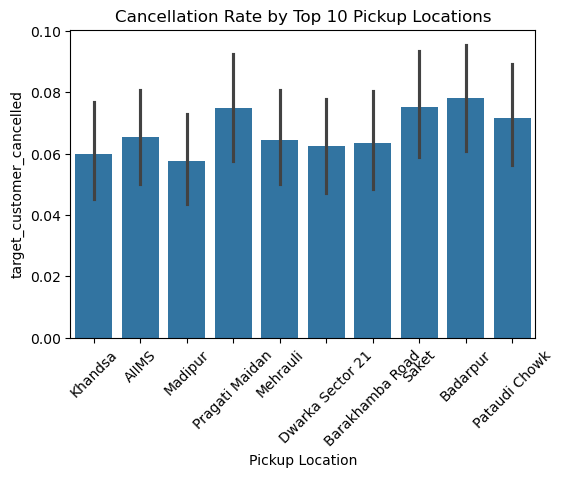

In [22]:
# 5. Top 10 Pickup Locations by Count
top_pickups = df['Pickup Location'].value_counts().nlargest(10).index
df_top_pickups = df[df['Pickup Location'].isin(top_pickups)]

plt.figure(figsize=(6, 4))
sns.barplot(data=df_top_pickups, x='Pickup Location', y='target_customer_cancelled')
plt.title("Cancellation Rate by Top 10 Pickup Locations")
plt.xticks(rotation=45)
plt.show()

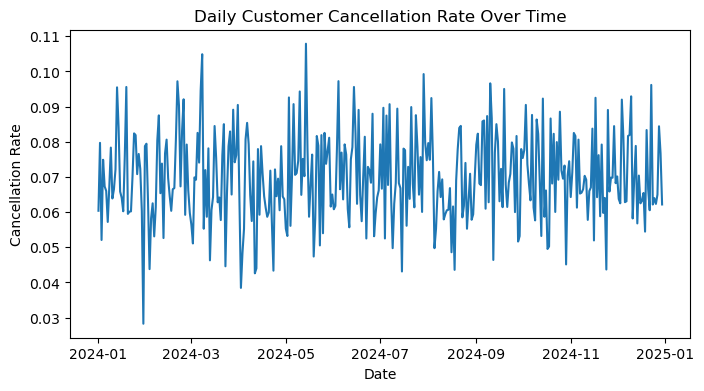

In [23]:
# 6. Trend of Cancellations Over Time (Daily)
df_daily = df.groupby('Date')['target_customer_cancelled'].mean().reset_index()

plt.figure(figsize=(8, 4))
sns.lineplot(data=df_daily, x='Date', y='target_customer_cancelled')
plt.title("Daily Customer Cancellation Rate Over Time")
plt.ylabel("Cancellation Rate")
plt.xlabel("Date")
plt.show()

## 5. Feature Engineering

### 5.1 Handling drop location and pickup location 
These 2 columns has 176 unique values 

In [24]:
print(df['Drop Location'].nunique())
print(df['Pickup Location'].nunique())

176
176


In [25]:
# Drop location
top_drop_location = df['Drop Location'].value_counts().index[:10].tolist()

def group_drop_location(drop_location):
    if drop_location in top_drop_location:
        return drop_location
    else:
        return 'Other'

df['top_drop_location'] = df['Drop Location'].apply(group_drop_location)

In [26]:
# Pickup location
top_pickup_location = df['Pickup Location'].value_counts().index[:10].tolist()

def group_pickup_location(pickup_location):
    if pickup_location in top_pickup_location:
        return pickup_location
    else:
        return 'Other'

df['top_pickup_location'] = df['Pickup Location'].apply(group_pickup_location)

### 5.2 Creating new column from customer ID

In [27]:
# Customer Booking Frequency
cust_counts = df['Customer ID'].value_counts().to_dict()
df['customer_total_bookings'] = df['Customer ID'].map(cust_counts)

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 31 columns):
 #   Column                             Non-Null Count   Dtype         
---  ------                             --------------   -----         
 0   Date                               150000 non-null  datetime64[ns]
 1   Time                               150000 non-null  object        
 2   Booking ID                         150000 non-null  object        
 3   Booking Status                     150000 non-null  object        
 4   Customer ID                        150000 non-null  object        
 5   Vehicle Type                       150000 non-null  object        
 6   Pickup Location                    150000 non-null  object        
 7   Drop Location                      150000 non-null  object        
 8   Avg VTAT                           150000 non-null  float64       
 9   Avg CTAT                           150000 non-null  float64       
 10  Cancelled Rides by C

### 6. Finding Class Weights
It will be helpful while training our data with XGBoost Algorithm

In [29]:
from sklearn.utils.class_weight import compute_class_weight

# Compute class weights using sklearn
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1]),
    y=df['target_customer_cancelled']
)

weights = dict(enumerate(class_weights))
print("Class Weights:", weights)

Class Weights: {0: np.float64(0.5376344086021505), 1: np.float64(7.142857142857143)}


## 7. Train / Test Split

In [30]:
numeric_cols         = ["Avg VTAT", "Avg CTAT", "Booking Value", "Ride Distance", "Driver Ratings", "Customer Rating"]
normal_cat_cols         = ["Vehicle Type", "top_pickup_location", "top_drop_location", "Payment Method"]
other_cat_cols = ["hour", "day", "month", "weekday", "customer_total_bookings", "is_weekend"]

feature_col = numeric_cols + normal_cat_cols + other_cat_cols

In [31]:
X = df[feature_col]
y = df['target_customer_cancelled']

In [32]:
print(X.shape)
print(y.shape)

(150000, 16)
(150000,)


In [33]:
# X.info()

In [34]:
# X.columns.to_list()

In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, stratify=y, random_state=42)

In [36]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(105000, 16)
(45000, 16)
(105000,)
(45000,)


## 8. Preprocessing: `ColumnTransformer` + `Pipeline`

In [37]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [38]:
#1. Numerical features
numeric_pipeline = Pipeline(steps=[
    ('impute_median', SimpleImputer(strategy="median")),
    ('scale', StandardScaler()),
])

#2. Nominal Features
normal_cat_pipeline = Pipeline(steps=[
    ('impute_mode_2', SimpleImputer(strategy="most_frequent")),
    ('encode', OneHotEncoder(handle_unknown="ignore"))
])

#3. Other categorical Features
other_cat_pipeline = Pipeline(steps=[
    ('impute_mode', SimpleImputer(strategy="most_frequent"))
])

preprocessor = ColumnTransformer(transformers=[
    ("numerical", numeric_pipeline, numeric_cols),
    ("categorical", normal_cat_pipeline, normal_cat_cols), 
    ("other_categorical", other_cat_pipeline, other_cat_cols)
])

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerical', ...), ('categorical', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` a

## 9. Trying Multiple Algorithms
### a. Decision Tree

In [39]:
from sklearn.metrics import precision_score, recall_score, roc_auc_score, f1_score, accuracy_score

In [45]:
from sklearn.tree import DecisionTreeClassifier

dt_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('decision tree', DecisionTreeClassifier(class_weight="balanced",random_state=42))
])

dt_pipeline.fit(X_train, y_train)
dt_preds = dt_pipeline.predict(X_test)

dt_accuracy = accuracy_score(y_test, dt_preds)
dt_precision = precision_score(y_test, dt_preds)
dt_recall = recall_score(y_test, dt_preds)
dt_f1 = f1_score(y_test, dt_preds)

# for auc-roc score
dt_prob = dt_pipeline.predict_proba(X_test)[:, 1]
dt_roc_auc_score = roc_auc_score(y_test, dt_prob)

print(f"accuracy score : {dt_accuracy}")
print(f"precision score : {dt_precision}")
print(f"recall score : {dt_recall}")
print(f"f1 score : {dt_f1}")
print(f"🎯 ROC AUC Score: {dt_roc_auc_score}")

accuracy score : 0.9475555555555556
precision score : 0.6292539267015707
recall score : 0.6104761904761905
f1 score : 0.6197228488559459
🎯 ROC AUC Score: 0.7917672981737499


In [ ]:
model.predict_proba(row)

### b. Random Forest

In [40]:
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('random forest', RandomForestClassifier(class_weight= "balanced", random_state=42))
])

rf_pipeline.fit(X_train, y_train)
rf_preds = rf_pipeline.predict(X_test)



rf_accuracy = accuracy_score(y_test, rf_preds)
rf_precision = precision_score(y_test, rf_preds)
rf_recall = recall_score(y_test, rf_preds)
rf_f1 = f1_score(y_test, rf_preds)

# for auc-roc score
rf_prob = rf_pipeline.predict_proba(X_test)[:, 1]
rf_roc_auc_score = roc_auc_score(y_test, rf_prob)

print(f"accuracy score : {rf_accuracy}")
print(f"precision score : {rf_precision}")
print(f"recall score : {rf_recall}")
print(f"f1 score : {rf_f1}")
print(f"🎯 ROC AUC Score: {rf_roc_auc_score}")

accuracy score : 0.9540222222222222
precision score : 0.7102294826915597
recall score : 0.5796825396825397
f1 score : 0.6383499388218843
🎯 ROC AUC Score: 0.9615292256926666


<Axes: >

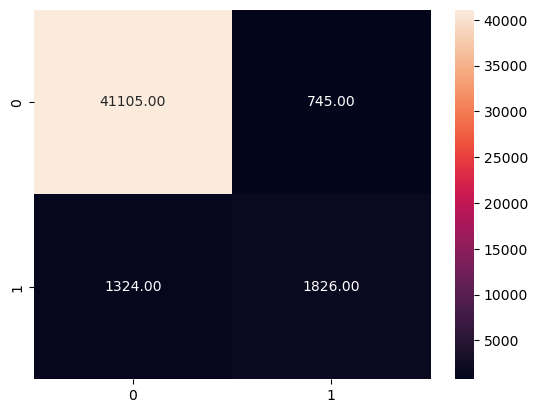

In [42]:
from sklearn.metrics import confusion_matrix

sns.heatmap(confusion_matrix(y_test,rf_preds), annot=True, fmt=".2f",
            xticklabels=rf_pipeline.classes_, yticklabels=rf_pipeline.classes_)

In [43]:
# Great accuracy, roc and f1 score but we have to increase recall

### c. XGB

In [44]:
import xgboost as xgb

xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('XG Boost', xgb.XGBClassifier(objective='binary:logistic', eval_metric='auc',
    scale_pos_weight=13.29, random_state=42, n_jobs=-1))
])

xgb_pipeline.fit(X_train, y_train)
xgb_preds = xgb_pipeline.predict(X_test)


xgb_accuracy = accuracy_score(y_test, xgb_preds)
xgb_precision = precision_score(y_test, xgb_preds)
xgb_recall = recall_score(y_test, xgb_preds)
xgb_f1 = f1_score(y_test, xgb_preds)

# for auc-roc score
xgb_prob = xgb_pipeline.predict_proba(X_test)[:, 1]
xgb_roc_auc_score = roc_auc_score(y_test, xgb_prob)

print(f"accuracy score : {xgb_accuracy}")
print(f"precision score : {xgb_precision}")
print(f"recall score : {xgb_recall}")
print(f"f1 score : {xgb_f1}")
print(f"🎯 ROC AUC Score: {xgb_roc_auc_score}")

accuracy score : 0.8796666666666667
precision score : 0.3578154425612053
recall score : 0.9047619047619048
f1 score : 0.5128205128205128
🎯 ROC AUC Score: 0.963393040147162


<Axes: >

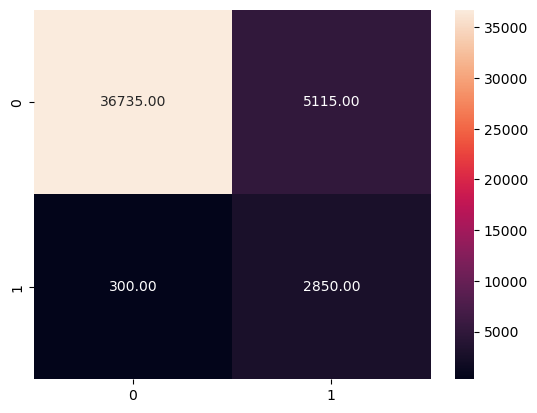

In [45]:
sns.heatmap(confusion_matrix(y_test,xgb_preds), annot=True, fmt=".2f",
            xticklabels=xgb_pipeline.classes_, yticklabels=xgb_pipeline.classes_)

## 10. Hyperparameter Tuning

In [46]:
from sklearn.model_selection import RandomizedSearchCV

rf_pipeline_ht = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("rf_classifier",   RandomForestClassifier(class_weight='balanced'))
])

param_distribution = {
    "rf_classifier__n_estimators" : [100,150, 200, 300],
    "rf_classifier__max_depth": [8, 12, 15, 20],
    "rf_classifier__min_samples_split": [2, 4, 6],
}

search = RandomizedSearchCV(
    estimator=rf_pipeline_ht,
    param_distributions=param_distribution,
    n_iter=10,
    cv=5,
    scoring="f1",
    random_state=42
    )

search.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...'balanced'))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'rf_classifier__max_depth': [8, 12, ...], 'rf_classifier__min_samples_split': [2, 4, ...], 'rf_classifier__n_estimators': [100, 150, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Al

In [47]:
print("Best Parameters: ", search.best_params_)
print("Best CV Macro-F1: ", search.best_score_)

Best Parameters:  {'rf_classifier__n_estimators': 150, 'rf_classifier__min_samples_split': 2, 'rf_classifier__max_depth': 20}
Best CV Macro-F1:  0.44401306132556123


## 11. Final Evaluation on the Test Set

In [48]:
best_pipeline = search.best_estimator_

rf_best_preds = best_pipeline.predict(X_test)

rf_best_accuracy = accuracy_score(y_test, rf_best_preds)
rf_best_precision = precision_score(y_test, rf_best_preds)
rf_best_recall = recall_score(y_test, rf_best_preds)
rf_best_f1 = f1_score(y_test, rf_best_preds)

# for roc auc score
rf_best_prob = best_pipeline.predict_proba(X_test)[:, 1]
rf_best_roc_auc_score = roc_auc_score(y_test, rf_best_prob)

print(f"accuracy score : {rf_best_accuracy}")
print(f"precision score : {rf_best_precision}")
print(f"recall score : {rf_best_recall}")
print(f"f1 score : {rf_best_f1}")
print(f"🎯 ROC AUC Score: {rf_best_roc_auc_score}")

accuracy score : 0.8195777777777777
precision score : 0.27631223552714507
recall score : 0.9742857142857143
f1 score : 0.43052535596549063
🎯 ROC AUC Score: 0.9625106749350477


<Axes: >

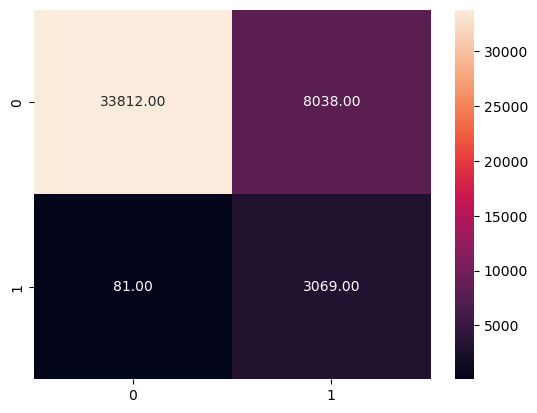

In [49]:
from sklearn.metrics import confusion_matrix

sns.heatmap(confusion_matrix(y_test,rf_best_preds), annot=True, fmt=".2f",
            xticklabels=best_pipeline.classes_, yticklabels=best_pipeline.classes_)

## 12. Saving the Final Model Artifact

In [50]:
import joblib

joblib.dump(best_pipeline, "uber_ml_pipeline.pkl",compress=3)

['uber_ml_pipeline.pkl']

## 13. Summary & Key Takeaways
* ROC AUC: 0.962
* Recall (Class 1): 97.4% → very few missed cancellations
* F1-score (Class 1): 0.430 → strong start despite class imbalance